<a href="https://colab.research.google.com/github/NiyatiBisht08/semantic-image-retrieval-cnn-vs-vit/blob/main/Semantic_Image_Retrieval_using_CNN_vs_Transformer_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Dataset


In [1]:
import torch
import torchvision
import torchvision.transforms as transforms

In [2]:
# using Caltech101 since it has diverse categories → good for testing retrieval
# also images are not too small like CIFAR, so embeddings should be meaningful
# CIFAR - imgs blurred upon resizing

In [3]:
#dataset
#transformed for ResNet
transform = transforms.Compose([
    transforms.Resize((224,224)), # resizing to 224 since pretrained models expect this input size
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])

dataset = torchvision.datasets.Caltech101(
    root='.data',
    download=True,
    transform=transform
)

# considering smaller dataset of 300 to intialize and build the pipeline
# subset_size = 300
# dataset = torch.utils.data.Subset(dataset, range(subset_size))

import random
indices = random.sample(range(len(dataset)), 1000)
dataset = torch.utils.data.Subset(dataset, indices)

100%|██████████| 137M/137M [00:06<00:00, 21.3MB/s]


In [4]:
print("Dataset size:", len(dataset))

Dataset size: 1000


In [5]:
print(dataset.dataset.categories)

['Faces', 'Faces_easy', 'Leopards', 'Motorbikes', 'accordion', 'airplanes', 'anchor', 'ant', 'barrel', 'bass', 'beaver', 'binocular', 'bonsai', 'brain', 'brontosaurus', 'buddha', 'butterfly', 'camera', 'cannon', 'car_side', 'ceiling_fan', 'cellphone', 'chair', 'chandelier', 'cougar_body', 'cougar_face', 'crab', 'crayfish', 'crocodile', 'crocodile_head', 'cup', 'dalmatian', 'dollar_bill', 'dolphin', 'dragonfly', 'electric_guitar', 'elephant', 'emu', 'euphonium', 'ewer', 'ferry', 'flamingo', 'flamingo_head', 'garfield', 'gerenuk', 'gramophone', 'grand_piano', 'hawksbill', 'headphone', 'hedgehog', 'helicopter', 'ibis', 'inline_skate', 'joshua_tree', 'kangaroo', 'ketch', 'lamp', 'laptop', 'llama', 'lobster', 'lotus', 'mandolin', 'mayfly', 'menorah', 'metronome', 'minaret', 'nautilus', 'octopus', 'okapi', 'pagoda', 'panda', 'pigeon', 'pizza', 'platypus', 'pyramid', 'revolver', 'rhino', 'rooster', 'saxophone', 'schooner', 'scissors', 'scorpion', 'sea_horse', 'snoopy', 'soccer_ball', 'stapler

### Load ResNet50 model

In [6]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet50(pretrained=True)
model = nn.Sequential(*list(model.children())[:-1]) # removing final FC layer, we only want feature embedding - classifier output is not useful
model.eval()


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 312MB/s]


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [7]:

embeddings = []
image_paths = []
with torch.no_grad():
  for img, label in dataset:
    img = img.unsqueeze(0)
    # Check if img has 1 channel and repeat it to 3 channels
    if img.shape[1] == 1:
      img = img.repeat(1, 3, 1, 1) # Repeat along channel dimension
    emb = model(img)
    emb = emb.squeeze().numpy()
    embeddings.append(emb)

# noticed some images are grayscale - converting to 3 channels in initial transformation
# otherwise ResNet throws channel mismatch error

In [8]:
print(len(embeddings))
print(embeddings[0].shape)

1000
(2048,)


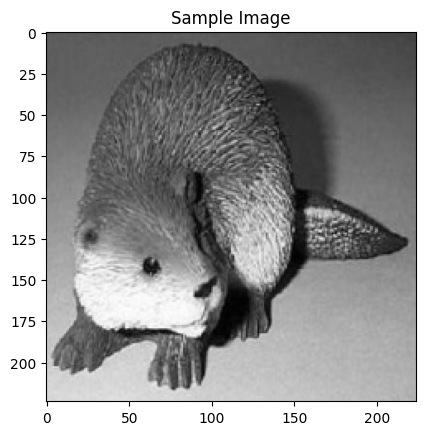

In [9]:
import matplotlib.pyplot as plt

img, _ = dataset[97]
plt.imshow(img.permute(1,2,0))
plt.title("Sample Image")
plt.show()

### ResNet50 Model - Similarity Search

In [10]:
# using cosine similarity since direction matters more than magnitude in embeddings
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# embedding to array
resnet_embeddings = np.array(embeddings)

query_idx = 0
query_resnet_embeddings = resnet_embeddings[query_idx].reshape(1, -1)

similarities = cosine_similarity(query_resnet_embeddings, resnet_embeddings)[0]


In [11]:
# retrieve top-k
top_k = 5

# sorting similarities to get most similar images (excluding the query itself)
similar_indices = np.argsort(similarities)[-top_k-1:-1][::-1]

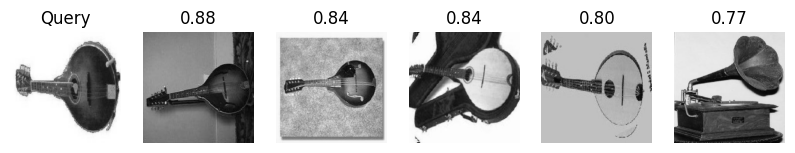

In [12]:
# visual output for resnet - retrival of similar images
# not good results - since less dataset used plus resnet focuses on local features
import matplotlib.pyplot as plt

# show query image
plt.figure(figsize=(10,3))

plt.subplot(1, top_k+1, 1)
img, _ = dataset[query_idx]
plt.imshow(img.permute(1,2,0))
plt.title("Query")
plt.axis('off')

# show similar images
for i, idx in enumerate(similar_indices):
    plt.subplot(1, top_k+1, i+2)
    img, _ = dataset[idx]
    plt.imshow(img.permute(1,2,0))
    plt.title(f"{similarities[idx]:.2f}")
    plt.axis('off')

plt.show()

### t-SNE

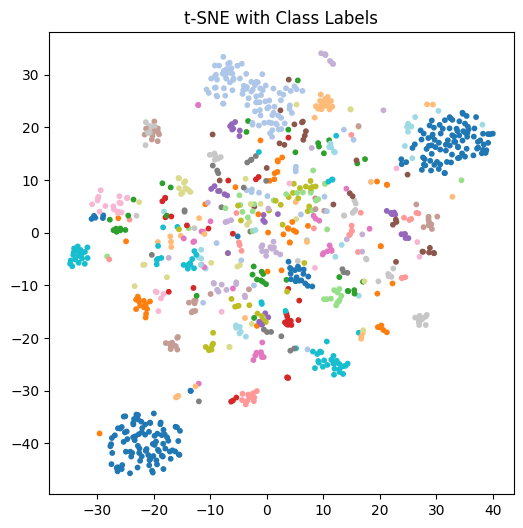

In [13]:

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

embeddings_array = np.array(resnet_embeddings)

tsne = TSNE(n_components=2, random_state=42)
reduced = tsne.fit_transform(embeddings_array)

labels = []
for i in range(len(dataset)):
    _, label = dataset[i]
    labels.append(label)

plt.figure(figsize=(6,6))

scatter = plt.scatter(
    reduced[:,0],
    reduced[:,1],
    c=labels,
    cmap='tab20',
    s=10
)

plt.title("t-SNE with Class Labels")
# plt.colorbar(scatter)

plt.show()

In [14]:
print("Embedding shape:", embeddings_array.shape)
print("Sample similarity:", similarities[:5])

Embedding shape: (1000, 2048)
Sample similarity: [0.9999999  0.6055531  0.5864987  0.5694952  0.62910473]


### Load ViT model

In [15]:
# VIT
import timm

vit = timm.create_model('vit_base_patch16_224', pretrained=True)
# removing classifier
vit.reset_classifier(0)
vit.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [16]:
vit_embeddings = []

with torch.no_grad():
    for img, label in dataset:
        img = img.unsqueeze(0)
        emb = vit(img)
        emb = emb.squeeze().numpy()
        vit_embeddings.append(emb)

In [17]:
vit_embeddings_array = np.array(vit_embeddings)

In [18]:
# resnet
tsne_resnet = TSNE(n_components=2, random_state=42)
resnet_2d = tsne_resnet.fit_transform(np.array(embeddings))

# vit
tsne_vit = TSNE(n_components=2, random_state=42)
vit_2d = tsne_vit.fit_transform(vit_embeddings_array)

### ResNet vs ViT : t-SNE

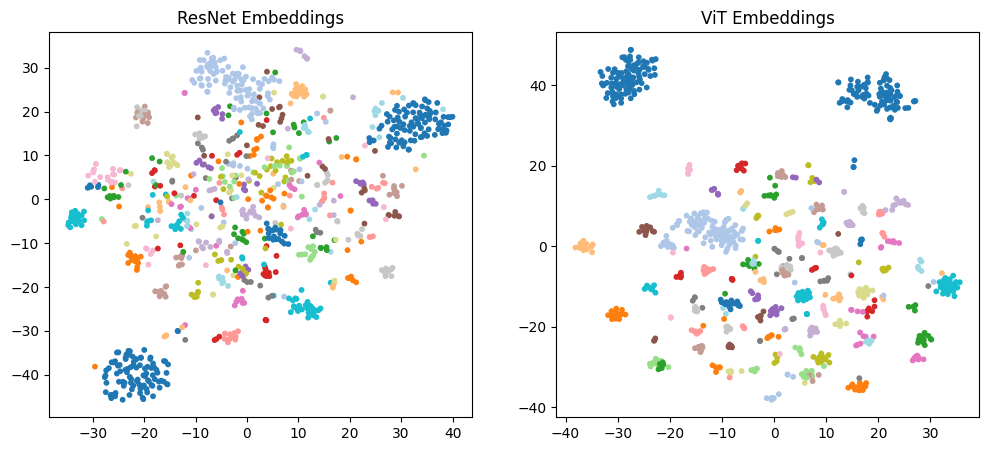

In [19]:
# vit better results as it focuses on global relationship
plt.figure(figsize=(12,5))

# resnet
plt.subplot(1,2,1)
plt.scatter(resnet_2d[:,0], resnet_2d[:,1], c=labels, cmap='tab20', s=10)
plt.title("ResNet Embeddings")

# vit
plt.subplot(1,2,2)
plt.scatter(vit_2d[:,0], vit_2d[:,1], c=labels, cmap='tab20', s=10)
plt.title("ViT Embeddings")

plt.show()

In [20]:
# Observation:
# ViT embeddings seem to cluster better (confirmed via t-SNE)
# likely due to global attention vs local features in CNN

### ResNet vs ViT Retrieval Comparison

In [21]:
query_idx = 150


from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# resnet
resnet_query = embeddings[query_idx].reshape(1, -1)
resnet_sim = cosine_similarity(resnet_query, embeddings)[0]

# vit
vit_query = vit_embeddings[query_idx].reshape(1, -1)
vit_sim = cosine_similarity(vit_query, vit_embeddings)[0]

top_k = 5

# resnet indices
resnet_idx = np.argsort(resnet_sim)[-top_k-1:-1][::-1]

# vit indices
vit_idx = np.argsort(vit_sim)[-top_k-1:-1][::-1]


/tmp/ipykernel_3584/789329491.py:55: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0, 1, 0.92])


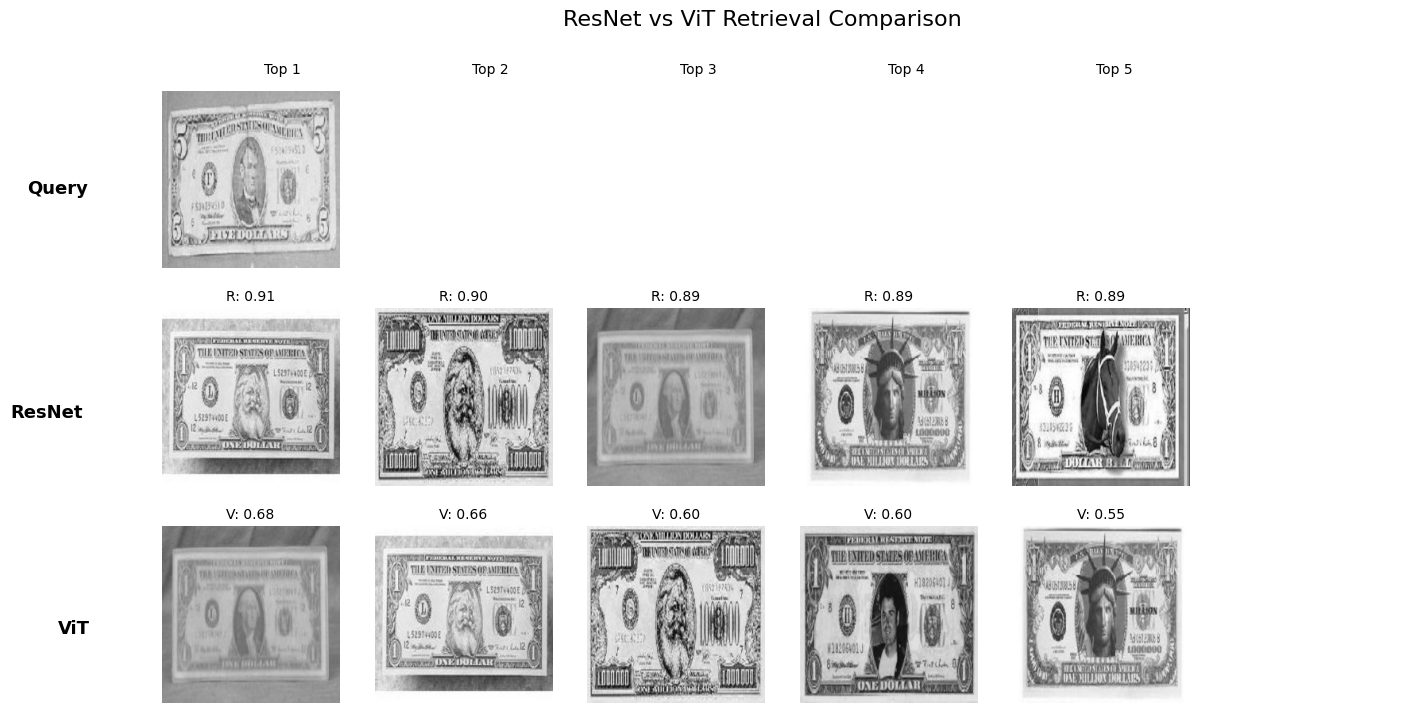

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))

# query
img, _ = dataset[query_idx]

for i in range(top_k+1):
    plt.subplot(3, top_k+1, i+1)

    if i == 0:
        plt.imshow(img.permute(1,2,0))
        plt.figtext(0.06, 0.75, "Query", ha='center', fontsize=13, weight='bold')
    else:
        plt.axis('off')  # keep rest empty

    plt.axis('off')

# resnet
for i, idx in enumerate(resnet_idx):
    plt.subplot(3, top_k+1, top_k+2 + i)

    img, _ = dataset[idx]
    plt.imshow(img.permute(1,2,0))
    plt.title(f"R: {resnet_sim[idx]:.2f}", fontsize=10)
    plt.axis('off')

plt.subplot(3, top_k+1, top_k+2)
plt.figtext(0.03, 0.47, "ResNet", fontsize=13, weight='bold')
plt.axis('off')

# vit
for i, idx in enumerate(vit_idx):
    plt.subplot(3, top_k+1, 2*(top_k+1) + 1 + i)

    img, _ = dataset[idx]
    plt.imshow(img.permute(1,2,0))
    plt.title(f"V: {vit_sim[idx]:.2f}", fontsize=10)
    plt.axis('off')

plt.subplot(3, top_k+1, 2*(top_k+1) + 1)
plt.figtext(0.06, 0.20, "ViT", fontsize=13, weight='bold')
plt.axis('off')

plt.suptitle("ResNet vs ViT Retrieval Comparison", fontsize=16)

for i in range(top_k):
    plt.text(
        0.2 + i*0.13, 0.90,
        f"Top {i+1}",
        transform=plt.gcf().transFigure,
        ha='center'
    )

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

### Observations - Precision@k

In [23]:
# precision@k
# using precision@k to quantify retrieval quality
# checks how many of top-k results belong to same class
def precision_at_k(query_idx, retrieved_indices, labels, k=5):
    query_label = labels[query_idx]
    correct = 0

    for idx in retrieved_indices[:k]:
        if labels[idx] == query_label:
            correct += 1

    return correct / k

In [24]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import random

def get_top_k(embeddings, query_idx, k=5):
    query = embeddings[query_idx].reshape(1, -1)
    sim = cosine_similarity(query, embeddings)[0]

    indices = np.argsort(sim)[-k-1:-1][::-1]
    return indices, sim

In [25]:
# evaluate 1 query
def evaluate_single_query(query_idx, embeddings, vit_embeddings, labels, k=5):

    resnet_idx, resnet_sim = get_top_k(embeddings, query_idx, k)
    resnet_p = precision_at_k(query_idx, resnet_idx, labels, k)

    vit_idx, vit_sim = get_top_k(vit_embeddings, query_idx, k)
    vit_p = precision_at_k(query_idx, vit_idx, labels, k)

    print(f"\nQuery Index: {query_idx}")
    print(f"ResNet P@{k}: {resnet_p:.2f}")
    print(f"ViT    P@{k}: {vit_p:.2f}")

    return resnet_p, vit_p

In [26]:
# evaluate many queries
# evaluating on multiple random queries to avoid bias from a single example

def evaluate_multiple_queries(embeddings, vit_embeddings, labels, num_queries=10, k=5):

    resnet_scores = []
    vit_scores = []

    indices = random.sample(range(len(labels)), num_queries)

    for q in indices:
        resnet_idx, _ = get_top_k(embeddings, q, k)
        vit_idx, _ = get_top_k(vit_embeddings, q, k)

        resnet_p = precision_at_k(q, resnet_idx, labels, k)
        vit_p = precision_at_k(q, vit_idx, labels, k)

        resnet_scores.append(resnet_p)
        vit_scores.append(vit_p)

        print(f"Query {q}: ResNet={resnet_p:.2f}, ViT={vit_p:.2f}")

    print("\n--------------")
    print("FINAL RESULTS :-")
    print(f"Avg ResNet P@{k}: {np.mean(resnet_scores):.3f}") # averaging results to get more stable performance estimate
    print(f"Avg ViT    P@{k}: {np.mean(vit_scores):.3f}")

    return resnet_scores, vit_scores

In [27]:
evaluate_single_query(query_idx, embeddings=embeddings, vit_embeddings=vit_embeddings, labels=labels)

resnet_scores, vit_scores = evaluate_multiple_queries(
    embeddings,
    vit_embeddings,
    labels,
    num_queries=10,
    k=5
)


Query Index: 150
ResNet P@5: 1.00
ViT    P@5: 1.00
Query 708: ResNet=1.00, ViT=1.00
Query 34: ResNet=0.60, ViT=1.00
Query 757: ResNet=0.40, ViT=1.00
Query 372: ResNet=0.60, ViT=1.00
Query 104: ResNet=0.00, ViT=0.60
Query 537: ResNet=1.00, ViT=1.00
Query 148: ResNet=1.00, ViT=1.00
Query 391: ResNet=1.00, ViT=1.00
Query 531: ResNet=0.60, ViT=1.00
Query 284: ResNet=0.80, ViT=0.80

--------------
FINAL RESULTS :-
Avg ResNet P@5: 0.700
Avg ViT    P@5: 0.940


### Failure Case

In [28]:
# identifying queries where model performs poorly (low precision)
# helps understand limitations

In [29]:
def find_failure_cases(embeddings, vit_embeddings, labels, k=5, threshold=0.4):
    failures = []

    for q in range(len(labels)):
        resnet_idx, _ = get_top_k(embeddings, q, k)
        vit_idx, _ = get_top_k(vit_embeddings, q, k)

        resnet_p = precision_at_k(q, resnet_idx, labels, k)
        vit_p = precision_at_k(q, vit_idx, labels, k)

        # failure condition
        if resnet_p < threshold or vit_p < threshold:
            failures.append((q, resnet_p, vit_p))

    return failures

In [30]:
failures = find_failure_cases(embeddings, vit_embeddings, labels)

# sort by worst performance
failures = sorted(failures, key=lambda x: min(x[1], x[2]))

print("Top failure cases:")
for f in failures[:5]:
    print(f)

Top failure cases:
(5, 0.0, 0.6)
(8, 0.0, 0.8)
(9, 0.0, 0.4)
(14, 0.0, 0.6)
(60, 0.0, 1.0)


query_idx:  5


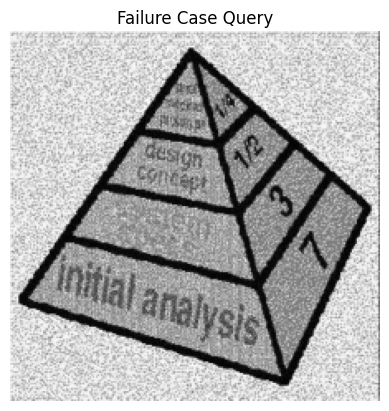

In [31]:
# failure likely due to background similarity or texture bias
# vit handles this case better than resnet
query_idx = failures[0][0]

img, label = dataset[query_idx]

plt.imshow(img.permute(1,2,0))

label_name = dataset.dataset.categories[label]
print("query_idx: ", query_idx)
plt.xlabel(label_name, fontsize=10)

plt.title("Failure Case Query")
plt.axis('off')
plt.show()